# **Yüz Tanıma**

Bu derste, python kütüphanesi kullanarak basit Yüz Tanımaları uygulayacağız.

1. Kurulum `face-recognition`
2. Yüz benzerliğini kontrol etme
3. Bir görüntüdeki Yüzleri Tanıma


In [12]:
!pip install face-recognition

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/100.1 MB ? eta -:--:--
     ---------------------------------------- 0.5/100.1 MB 5.6 MB/s eta 0:00:18
     - ------------------------------------- 3.1/100.1 MB 11.5 MB/s eta 0:00:09
     -- ------------------------------------ 5.8/100.1 MB 13.6 MB/s eta 0:00:07
     --- ----------------------------------- 9.2/100.1 MB 13.3 MB/s eta 0:00:07
     ---- --------------------------------- 11.3/100.1 MB 12.4 MB/s eta 0:00:08
     ----- -------------------------------- 14.2/100.1 MB 12.3 MB/s eta 0:00:07
     ------ ------------------------------- 17.6/100.1 MB 13.0 MB/s eta 0:00:07
     ------- ------------------------------ 20.4/100.1 MB 13.0 MB/s eta 0:00:07
     --------- ---------------------------- 24.1/100.1 MB 13.5 MB/s eta 0:00:06
     ---------- --------------------------- 27.3/100.1 MB 13.7 MB/s eta 0:00:06
     ----------- -------------------------- 30.9/

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


## **İki Yüz Arasındaki Benzerliği Kontrol Edelim**

In [14]:
def imshow(title = "Image", image = None, size = 10):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

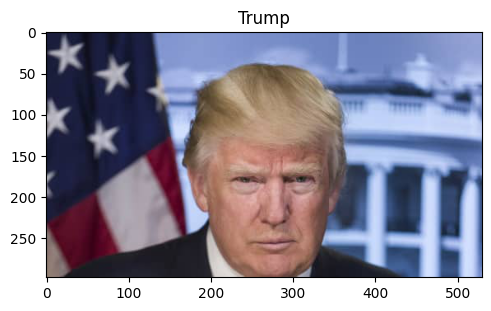

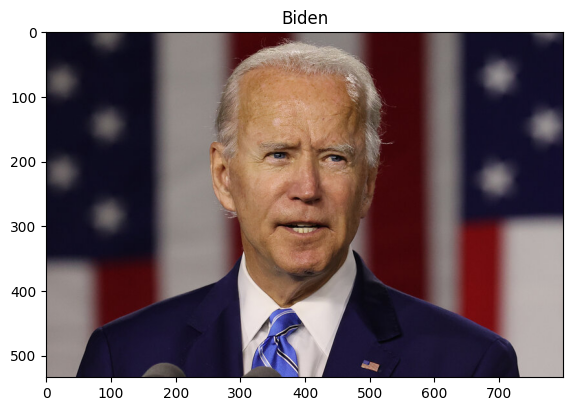

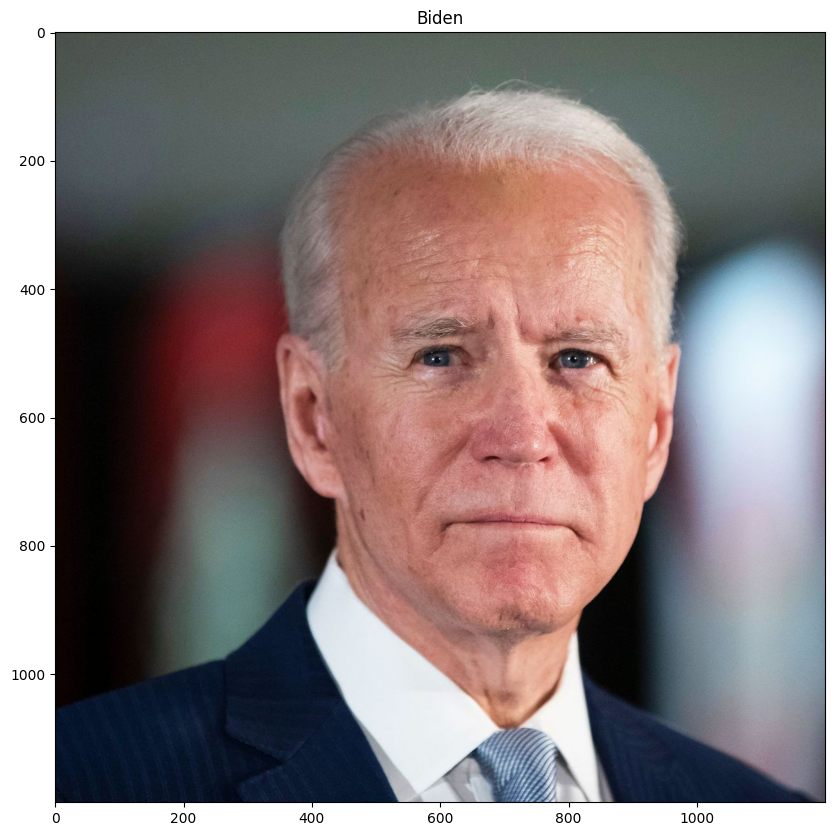

In [16]:
import cv2
from matplotlib import pyplot as plt

biden = cv2.imread('../files/images/biden.jpg')
biden2 = cv2.imread('../files/images/biden2.jpg')
trump = cv2.imread('../files/images/trump2.jpg')

imshow('Trump', trump)
imshow('Biden', biden)
imshow('Biden', biden2)

In [32]:
!pip install --upgrade cmake
!pip install --upgrade dlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/37.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/37.6 MB ? eta -:--:--
   - -------------------------------------- 1.8/37.6 MB 7.2 MB/s eta 0:00:05
   ----- ---------------------------------- 5.2/37.6 MB 11.4 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/37.6 MB 13.1 MB/s eta 0:00:03
   ------------ --------------------------- 12.1/37.6 MB 14.0 MB/s eta 0:00:02
   --------------- ------------------------ 14.9/37.6 MB 13.8 MB/s eta 0:00:02
   ------------------- -------------------- 18.1/37.6 MB 13.9 MB/s eta 0:00:02
   ---------------------- ----------------- 20.7/37.6 MB 13.6 MB/s eta 0:00:02
   ------------------------ --------------- 23.1/37.6 MB 13.3 MB/s eta 0:00:02
   --------------------------- ------------ 26.2/37.6 MB 13.3 MB/s eta 0:00:01
   ------------------------------ --------- 28.3/37.6 MB 13.0 MB/s eta 0:00

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


Defaulting to user installation because normal site-packages is not writeable


In [18]:
import face_recognition

known_image = face_recognition.load_image_file("../files/images/biden.jpg")
unknown_image = face_recognition.load_image_file("../files/images/trump.jpg")

biden_encoding = face_recognition.face_encodings(known_image)[0]
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]

result = face_recognition.compare_faces([biden_encoding], unknown_encoding)
print(f'Face Match is {result[0]}')

Face Match is False


### **Şimdi bunu iki Biden resmiyle deneyelim**

In [23]:
import face_recognition

known_image = face_recognition.load_image_file("../files/images/biden.jpg")
unknown_image = face_recognition.load_image_file("../files/images/biden2.jpg")

biden_encoding = face_recognition.face_encodings(known_image)[0]
unknown_encoding = face_recognition.face_encodings(unknown_image)[0]

result = face_recognition.compare_faces([biden_encoding], unknown_encoding)
print(f'Face Match is {result[0]}')

Face Match is True


## **3. Bir görüntüdeki Yüzleri Tanıma**

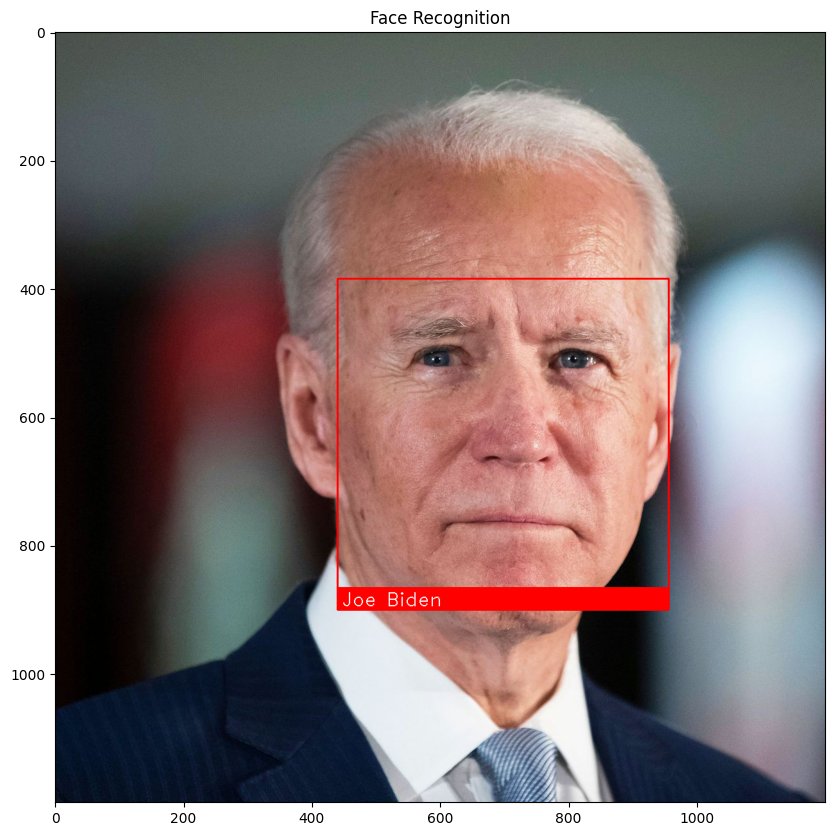

In [40]:
import face_recognition
import cv2
import numpy as np
from matplotlib import pyplot as plt

#face_encodings() resmi analiz ederek 128 boyutlu bir yüz vektörü oluşturur.
#Bu vektörler, yüzleri tanımak için referans olarak kullanılır.

# Bir resim yükleyelim ve onu kodlayalım
trump_image = face_recognition.load_image_file("../files/images/trump.jpg")
trump_face_encoding = face_recognition.face_encodings(trump_image)[0]

# Bir resim yükleyelim ve onu kodlayalım
biden_image = face_recognition.load_image_file("../files/images/biden.jpg")
biden_face_encoding = face_recognition.face_encodings(biden_image)[0]

# Bilinen yüz kodlamalarının ve adları için dizi oluşturalım
known_face_encodings = [
    trump_face_encoding,
    biden_face_encoding
]
known_face_names = [
    "Donald Trump",
    "Joe Biden"
]

# Bazı değişkenleri başlatalım
face_locations = []
face_encodings = []
face_names = []
process_this_frame = True


# Videonun tek bir karesini yakala (burada zaten resim)
frame = cv2.imread('../files/images/biden2.jpg')

# Daha hızlı yüz tanıma işlemi için video karesini 1/4 boyutuna yeniden boyutlandıralım
small_frame = cv2.resize(frame, (0, 0), fx=0.25, fy=0.25)

# Görüntüyü BGR renginden (OpenCV'nin kullandığı) RGB rengine (face_recognition'ın kullandığı) dönüştürün
rgb_small_frame = small_frame[:, :, ::-1] # BGRtoRGB gibi

# Only process every other frame of video to save time
if process_this_frame:
    # Find all the faces and face encodings in the current frame of video
    rgb_small_frame = np.ascontiguousarray(rgb_small_frame) #OpenCV’den gelen array bazen hafızada parçalı (non-contiguous) olur.
    #Dlib, yüz tanıma için contiguous array bekler.Bu satır hatayı engeller.
    face_locations = face_recognition.face_locations(rgb_small_frame) #esimdeki yüzlerin koordinatlarını bulur (top, right, bottom, left) formatında.
    face_encodings = face_recognition.face_encodings(rgb_small_frame, face_locations) #bulunan yüzlerden 128 boyutlu vektörler üretir.

    face_names = []

    #Yüzleri bilinenlerle karşılaştırma
    for face_encoding in face_encodings:
        # Yüzü bilinen yüz(ler) ile eşleşip eşleşmediğine bakın
        matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
        name = "Unknown"

        # # If a match was found in known_face_encodings, just use the first one.
        # if True in matches:
        #     first_match_index = matches.index(True)
        #     name = known_face_names[first_match_index]

        # Or instead, use the known face with the smallest distance to the new face
        face_distances = face_recognition.face_distance(known_face_encodings, face_encoding) 
        # her bilinen yüz ile mesafeyi ölçer (küçük mesafe → daha yakın eşleşme).
        best_match_index = np.argmin(face_distances)
        # en iyi eşleşmeyi seçer.
        if matches[best_match_index]:
            name = known_face_names[best_match_index]
        # eğer eşleşme varsa, name atanır; yoksa "Unknown" kalır.
        face_names.append(name)


# Sonuçları görüntüleyelim
for (top, right, bottom, left), name in zip(face_locations, face_names):
    # Tespit ettiğimiz çerçeve 1/4 boyutuna ölçeklendirildiği için yüz konumlarını yeniden ölçeklendirelim
    top *= 4
    right *= 4
    bottom *= 4
    left *= 4

    # Yüzün etrafına bir kutu çizelim
    cv2.rectangle(frame, (left, top), (right, bottom), (0, 0, 255), 2)

    # Yüzün alt kısmına ad içeren bir etiket çizelim
    cv2.rectangle(frame, (left, bottom - 35), (right, bottom), (0, 0, 255), cv2.FILLED)
    font = cv2.FONT_HERSHEY_DUPLEX
    cv2.putText(frame, name, (left + 6, bottom - 6), font, 1.0, (255, 255, 255), 1)

# Ortaya çıkan resmi görüntüleyelim
imshow('Face Recognition', frame)